In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import joblib

In [3]:
model = joblib.load(
    "../models/aqi_category_model.pkl"
)

print("Model loaded successfully!")

Model loaded successfully!


In [5]:
df = pd.read_csv(
    "../data/processed data/model_data.csv"
)

df.head()

,country,city,co_aqi_value,ozone_aqi_value,no2_aqi_value,pm2_5_aqi_value,aqi_category
0,Russian Federation,Praskoveya,1,36,0,51,Moderate
1,Brazil,Presidente Dutra,1,5,1,41,Good
2,Italy,Priolo Gargallo,1,39,2,66,Moderate
3,Poland,Przasnysz,1,34,0,20,Good
4,France,Punaauia,0,22,0,6,Good


In [7]:
rf = model.named_steps["model"]

In [9]:
preprocessor = model.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()

len(feature_names)

18962

In [11]:
feature_names

array(['categorical__country_Afghanistan', 'categorical__country_Albania',
       'categorical__country_Algeria', ..., 'remainder__ozone_aqi_value',
       'remainder__no2_aqi_value', 'remainder__pm2_5_aqi_value'],
      dtype=object)

In [13]:
importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance.head(20)

,feature,importance
18961,remainder__pm2_5_aqi_value,0.307262
18959,remainder__ozone_aqi_value,0.079345
18958,remainder__co_aqi_value,0.059108
74,categorical__country_India,0.039138
18960,remainder__no2_aqi_value,0.038032
179,categorical__country_United States of America,0.008612
124,categorical__country_Pakistan,0.007435
34,categorical__country_China,0.006951
138,categorical__country_Russian Federation,0.005663
22,categorical__country_Brazil,0.004743


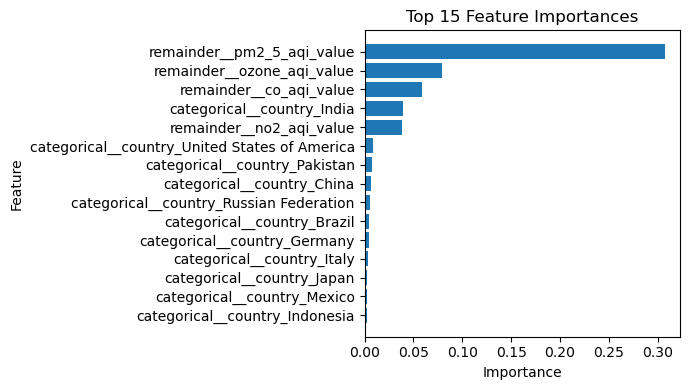

In [17]:
top_features = feature_importance.head(15)

plt.figure(figsize=(7, 4))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [19]:
pollutant_features = feature_importance[
    feature_importance["feature"].str.contains(
        "co_aqi|ozone_aqi|no2_aqi|pm25_aqi",
        case=False,
        regex=True
    )
]

pollutant_features

,feature,importance
18959,remainder__ozone_aqi_value,0.079345
18958,remainder__co_aqi_value,0.059108
18960,remainder__no2_aqi_value,0.038032


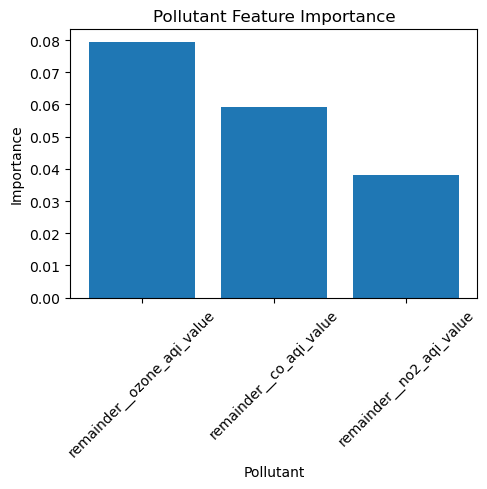

In [25]:
plt.figure(figsize=(5, 5))

plt.bar(
    pollutant_features["feature"],
    pollutant_features["importance"]
)

plt.title("Pollutant Feature Importance")
plt.xlabel("Pollutant")
plt.ylabel("Importance")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
feature_importance.to_csv(
    "../data/processed data/feature_importance.csv",
    index=False
)